In [2]:
!pip install keras-tcn

In [5]:
from google.colab import drive
import os, pathlib, shutil
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight
import seaborn as sn
from tcn import TCN

In [11]:
drive.mount('/content/drive')

REPO_URL   = "https://github.com/Svanzi/Tennis-Shot-Recognition.git"
BASE       = "/content/drive/MyDrive/University/Deep"
SPARSE_DIR = "Tennis-Shot-Recognition"
TARGET     = f"{BASE}/{SPARSE_DIR}"

os.makedirs(BASE, exist_ok=True)

from pathlib import Path
DATA_DIR = Path(TARGET) / "DataSet"
print("DATA_DIR =", DATA_DIR)

Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet


# Dataset upload and sequences creation

The structure of a sequence is (batch, T, D_part) + label

In [12]:
def idx_of(cols, prefixes):
  idx = []
  for p in prefixes:
    for suff in ['_x','_y']:
      name = p + suff
      if name in cols:
        idx.append(cols.get_loc(name))
  return idx

In [13]:
DATA_DIR = Path("/content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet")
players = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])

feature_cols = None
sequences = []        # List of dict: {"left_arm": (T,6), "right_arm":..., "torso":(T,8)}
sequence_labels = []  # A label for each CSV

for player in players:
  print(f"{player}")
  for shot_csv in sorted(player.glob("*.csv")):
    print(f"  {shot_csv}")
    df = pd.read_csv(shot_csv)
    if feature_cols is None:
      feature_cols = pd.Index([c for c in df.columns if c!= 'shot'])
      GROUPS = {
        'left_arm':   idx_of(feature_cols, ['left_shoulder',  'left_elbow',   'left_wrist'                        ]),
        'right_arm':  idx_of(feature_cols, ['right_shoulder', 'right_elbow',  'right_wrist'                       ]),
        'left_leg':   idx_of(feature_cols, ['left_hip',       'left_knee',    'left_ankle'                        ]),
        'right_leg':  idx_of(feature_cols, ['right_hip',      'right_knee',   'right_ankle'                       ]),
        'torso':      idx_of(feature_cols, ['left_hip',       'right_hip',     'left_shoulder',  'right_shoulder' ])
      }

    X_all = df[feature_cols].to_numpy()
    label = df["shot"].iloc[0]

    seq = { name: X_all[:, idx] for name, idx in GROUPS.items()}
    sequences.append(seq)
    print(f"{len(sequences)}")
    sequence_labels.append(label)
    print(f"{len(sequence_labels)}")

/content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_001.csv
1
1
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_002.csv
2
2
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_003.csv
3
3
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_004.csv
4
4
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_005.csv
5
5
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_006.csv
6
6
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_007.csv
7
7
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_008.csv
8
8
  /content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/DataSet/Alcaraz/backhand_009.csv
9
9
  /

Shapes check

In [14]:
T           = sequences[0]["torso"].shape[0]
D_left_arm  = sequences[0]["left_arm"].shape[1]
D_right_arm = sequences[0]["right_arm"].shape[1]
D_left_leg  = sequences[0]["left_leg"].shape[1]
D_right_leg = sequences[0]["right_leg"].shape[1]
D_torso     = sequences[0]["torso"].shape[1]

print(T, D_left_arm, D_right_arm, D_left_leg, D_right_leg, D_torso)

30 6 6 6 6 8


In [15]:
def pie_plot(shots, counts):

  fig, ax = plt.subplots()

  # Pie with percentages
  wedges, texts, autotexts = ax.pie(
      counts,
      autopct='%1.1f%%',
      startangle=90
  )

  ax.axis('equal')
  ax.set_title('Shots dataset')

  # Legend on the side with "label — count"
  legend_labels = [f"{label} — {cnt}" for label, cnt in zip(shots, counts)]
  ax.legend(
      wedges, legend_labels,
      title="Shots (counts)",
      loc="center left",
      bbox_to_anchor=(1.02, 0.5),
      frameon=False
  )

  plt.tight_layout()
  plt.show()

In [16]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(sequence_labels)  # {'forehand': N1, 'backhand': N2, 'neutral': N3, ...}
labels = list(counts.keys())
sizes  = list(counts.values())

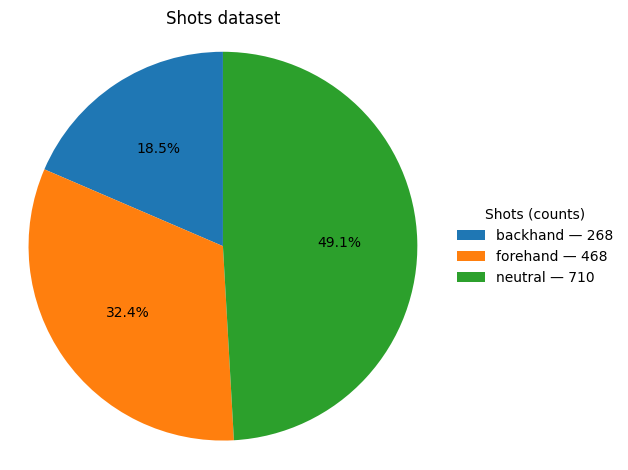

In [17]:
pie_plot(labels, sizes)

# Data Splitting

In [18]:
le = LabelEncoder()
y = le.fit_transform(sequence_labels)
num_classes = len(le.classes_)
y_cat = to_categorical(y, num_classes)

def stack_part(name):
  return np.stack([s[name] for s in sequences], axis=0)

X_left_arm  = stack_part("left_arm")
X_right_arm = stack_part("right_arm")
X_left_leg  = stack_part("left_leg")
X_right_leg = stack_part("right_leg")
X_torso     = stack_part("torso")

print(X_left_arm.shape)
print(X_right_arm.shape)
print(X_left_leg.shape)
print(X_right_leg.shape)
print(X_torso.shape)
print(f"{num_classes}")

(Xla_tr, Xla_te,
 Xra_tr, Xra_te,
 Xt_tr,  Xt_te,
 Xll_tr, Xll_te,
 Xrl_tr, Xrl_te,
 y_tr,   y_te) = train_test_split(
    X_left_arm, X_right_arm, X_torso, X_left_leg, X_right_leg, y,
    test_size=0.2, random_state=42, stratify=y
)

y_tr = to_categorical(y_tr, num_classes)
y_te = to_categorical(y_te, num_classes)

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y), # Classi uniche (0, 1, 2)
    y=y                   # Usa l'array 'y' (non categorico)
)

class_weights_dict = dict(zip(np.unique(y), weights))

print("Pesi delle classi calcolati:", class_weights_dict)

(1446, 30, 6)
(1446, 30, 6)
(1446, 30, 6)
(1446, 30, 6)
(1446, 30, 8)
3
Pesi delle classi calcolati: {np.int64(0): np.float64(1.7985074626865671), np.int64(1): np.float64(1.0299145299145298), np.int64(2): np.float64(0.6788732394366197)}


## Da valutare

In [19]:
def standardize_train_test(Xtr, Xte):
    mu = Xtr.reshape(-1, Xtr.shape[-1]).mean(axis=0)
    sd = Xtr.reshape(-1, Xtr.shape[-1]).std(axis=0) + 1e-8
    return (Xtr - mu)/sd, (Xte - mu)/sd, mu, sd

Xla_tr, Xla_te, mu_la,  sd_la = standardize_train_test(Xla_tr, Xla_te)
Xra_tr, Xra_te, mu_ra,  sd_ra = standardize_train_test(Xra_tr, Xra_te)
Xt_tr,  Xt_te,  mu_t,   sd_t  = standardize_train_test(Xt_tr,  Xt_te)
Xll_tr, Xll_te, mu_ll,  sd_ll = standardize_train_test(Xll_tr, Xll_te)
Xrl_tr, Xrl_te, mu_rl,  sd_rl = standardize_train_test(Xrl_tr, Xrl_te)

std_values_file_path = "/content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/"

np.savez(
    std_values_file_path + "Standardization_Values.npz",
    mu_la=mu_la,  sd_la=sd_la,
    mu_ra=mu_ra,  sd_ra=sd_ra,
    mu_t=mu_t,    sd_t=sd_t,
    mu_ll=mu_ll,  sd_ll=sd_ll,
    mu_rl=mu_rl,  sd_rl=sd_rl
)

# Plot Model's History

In [29]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

# Model

In [31]:
def brnn_tanh(units, name, rnn_type="simple", dropout=0.0, return_sequences=True):
  if rnn_type == "simple":
    rnn = layers.SimpleRNN(units, activation='tanh', return_sequences=return_sequences, dropout=dropout)

  elif rnn_type == "gru":
    rnn = layers.GRU(units, activation='tanh', return_sequences=return_sequences, dropout=dropout)

  return layers.Bidirectional(rnn, name=name)

In [32]:
def  bidirectional_lstm(units, name, dropout=0.0, return_sequences=False):
  lstm = layers.LSTM(units, return_sequences=return_sequences, dropout=dropout)
  return layers.Bidirectional(lstm, name=name)

In [33]:
def create_network(
    T=30,
    shape_left_arm=6,
    shape_right_arm=6,
    shape_left_leg=6,
    shape_right_leg=6,
    shape_trunk=8,
    n_classes=3,
    brnn_units=(64, 96, 128),
    lstm_units=256,
    rnn_type="simple",
    dropout=0.1
):

  # ==== Inputs ====

  in_left_arm  = Input(shape=(T, shape_left_arm),  name = "left_arm")
  in_right_arm = Input(shape=(T, shape_right_arm), name = "right_arm")
  in_left_leg  = Input(shape=(T, shape_left_leg),  name = "left_leg")
  in_right_leg = Input(shape=(T, shape_right_leg), name = "right_leg")
  in_trunk     = Input(shape=(T, shape_trunk),     name = "trunk")

  # ==== bl1 layer ====

  bl1_left_arm  =  brnn_tanh(brnn_units[0], "bl1_left_arm",   rnn_type, dropout)  (in_left_arm)
  bl1_right_arm =  brnn_tanh(brnn_units[0], "bl1_right_arm",  rnn_type, dropout)  (in_right_arm)
  bl1_trunk     =  brnn_tanh(brnn_units[0], "bl1_trunk",      rnn_type, dropout)  (in_trunk)
  bl1_left_leg  =  brnn_tanh(brnn_units[0], "bl1_left_leg",   rnn_type, dropout)  (in_left_leg)
  bl1_right_leg =  brnn_tanh(brnn_units[0], "bl1_right_leg",  rnn_type, dropout)  (in_right_leg)

  # ==== fl1 layer ====

  fl1_leftArm_trunk   = layers.Concatenate(name="fl1_leftArm_trunk")  ([bl1_left_arm,   bl1_trunk])
  fl1_rightArm_trunk  = layers.Concatenate(name="fl1_rightArm_trunk") ([bl1_right_arm,  bl1_trunk])
  fl1_leftLeg_trunk   = layers.Concatenate(name="fl1_lafetLeg_trunk") ([bl1_left_leg,   bl1_trunk])
  fl1_rightLeg_trunk  = layers.Concatenate(name="fl1_rightLeg_trunk") ([bl1_right_leg,  bl1_trunk])

  # ==== bl2 layer ====

  bl2_leftArm_trunk   = brnn_tanh(brnn_units[1], "bl2_leftArm_trunk",   rnn_type, dropout)  (fl1_leftArm_trunk)
  bl2_rightArm_trunk  = brnn_tanh(brnn_units[1], "bl2_rightArm_trunk",  rnn_type, dropout)  (fl1_rightArm_trunk)
  bl2_leftLeg_trunk   = brnn_tanh(brnn_units[1], "bl2_leftLeg_trunk",   rnn_type, dropout)  (fl1_leftLeg_trunk)
  bl2_rightLeg_trunk  = brnn_tanh(brnn_units[1], "bl2_rightLeg_trunk",  rnn_type, dropout)  (fl1_rightLeg_trunk)

  # ==== fl2 layer ====

  fl2_upperBody = layers.Concatenate(name="fl2_upperBody")  ([bl2_leftArm_trunk,  bl2_rightArm_trunk])
  fl2_lowerBody = layers.Concatenate(name="fl2_lowerBody")  ([bl2_leftLeg_trunk,  bl2_rightLeg_trunk])

  # ==== bl3 layer ====

  bl3_upperBody = brnn_tanh(brnn_units[2], "bl3_upperBody", rnn_type, dropout)  (fl2_upperBody)
  bl3_lowerBody = brnn_tanh(brnn_units[2], "bl3_lowerBody", rnn_type, dropout)  (fl2_lowerBody)

  # ==== fl3 layer ====

  fl3_wholeBody = layers.Concatenate(name="fl3_wholeBody") ([bl3_upperBody, bl3_lowerBody])

  # ==== bl4 layer ====

  bl4 = bidirectional_lstm(lstm_units, "bl4", dropout, return_sequences=False) (fl3_wholeBody)

  # ==== fully connected layer ====

  fc = layers.Dense(256, activation='relu', name="fc")(bl4)
  fc = layers.Dropout(0.3)(fc)

  # ==== softmax layer ====

  sl = layers.Dense(n_classes, activation="softmax", name="sl")(fc)

  model = models.Model(
      inputs=[in_left_arm, in_right_arm, in_trunk, in_left_leg, in_right_leg],
      outputs= sl,
      )

  return model

In [34]:
def model_training(model_type):

  if model_type == "simpleRNN":
    model = create_network(
        T=30,
        shape_left_arm=6,
        shape_right_arm=6,
        shape_left_leg=6,
        shape_right_leg=6,
        shape_trunk=8,
        n_classes=3,
        brnn_units=(64, 96, 128),
        lstm_units=256,
        rnn_type="simple",
        dropout=0.1
    )
  elif model_type == "gru":
    model = create_network(
        T=30,
        shape_left_arm=6,
        shape_right_arm=6,
        shape_left_leg=6,
        shape_right_leg=6,
        shape_trunk=8,
        n_classes=3,
        brnn_units=(64, 96, 128),
        lstm_units=256,
        rnn_type="gru",
        dropout=0.1
    )

  print("\n=================================================\n")
  print("\n\t\tModel created\n")
  print("\n=================================================\n")

  model.summary()

  model.compile(
      optimizer="adam",
      loss="categorical_crossentropy",
      metrics=["accuracy"]
      )

  if model_type == "simpleRNN":
    file_path = "weights_SimpleRNN.keras"
  elif model_type == "gru":
    file_path = "weights_GRU.keras"

  checkpointer = ModelCheckpoint(
    filepath=file_path,
    verbose=1,
    save_best_only=True,
    monitor='val_loss'
    )

  print("\n\t\tCheckpointer defined\n")

  early_stopper = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    verbose = False,
    restore_best_weights = True
    )

  print("\n\t\tEarly stopper defined\n")

  print("\n=================================================\n")
  print("\n\t\tStarting fitting process\n")
  print("\n=================================================\n")

  history = model.fit(
    [Xla_tr, Xra_tr, Xt_tr, Xll_tr, Xrl_tr], y_tr,
    validation_data = ([Xla_te, Xra_te, Xt_te, Xll_te, Xrl_te], y_te),
    epochs = 100,
    batch_size = 32,
    verbose=1,
    callbacks=[checkpointer, early_stopper],
    class_weight=class_weights_dict
    )


  results = model.evaluate(
    [Xla_te, Xra_te, Xt_te, Xrl_te, Xll_te],
    y_te,
    return_dict=True
    )

  print("\n\t\tEvaluation done\n")

  print("\n=================================================\n")
  print("\n\t\tResults\n")
  print("\n=================================================\n")

  plot_history(history)

  print(results)

  model_file_path = "/content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/"

  if model_type == "simpleRNN":
    model.save(model_file_path + "Shot_Classification_SimpleRNN.keras")
  elif model_type == "gru":
    model.save(model_file_path + "Shot_Classification_GRU.keras")

  print("\n\t\tModel saved\n")

  print("\n=================================================\n")
  print("\n\t\tConfusion matrix\n")
  print("\n=================================================\n")

  %matplotlib inline

  cm = confusion_matrix(y_true=np.argmax(y_te, axis=1), y_pred=np.argmax(model.predict([Xla_te, Xra_te, Xt_te, Xrl_te, Xll_te]), axis=1))
  df_cm = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
  plt.figure(figsize=(10,10))
  sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='.4g')
  plt.xlabel('Predicted Label', fontsize=20)
  plt.ylabel('True Label', fontsize=20)
  plt.show()

## Simple RNN Model




		Model created





Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_arm            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk (InputLayer)  │ (None, 30, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_arm           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_leg            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_leg           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_left_arm        │ (None, 30, 128)   │      9,088 │ left_arm[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_trunk           │ (None, 30, 128)   │      9,344 │ trunk[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_right_arm       │ (None, 30, 128)   │      9,088 │ right_arm[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_left_leg        │ (None, 30, 128)   │      9,088 │ left_leg[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_right_leg       │ (None, 30, 128)   │      9,088 │ right_leg[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_leftArm_trunk   │ (None, 30, 256)   │          0 │ bl1_left_arm[0][… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_rightArm_trunk  │ (None, 30, 256)   │          0 │ bl1_right_arm[0]… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_lafetLeg_trunk  │ (None, 30, 256)   │          0 │ bl1_left_leg[0][… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_rightLeg_trunk  │ (None, 30, 256)   │          0 │ bl1_right_leg[0]… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_leftArm_trunk   │ (None, 30, 192)   │     67,776 │ fl1_leftArm_trun… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_rightArm_trunk  │ (None, 30, 192)   │     67,776 │ fl1_rightArm_tru… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_leftLeg_trunk   │ (None, 30, 192)   │     67,776 │ fl1_lafetLeg_tru… │
│ (Bidirectional)     │                   │            │                 

 Total params: 2,286,467 (8.72 MB)

 Trainable params: 2,286,467 (8.72 MB)

 Non-trainable params: 0 (0.00 B)


		Checkpointer defined


		Early stopper defined




		Starting fitting process



Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.5839 - loss: 0.8590
Epoch 1: val_loss improved from inf to 0.43668, saving model to weights_SimpleRNN.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 65s 848ms/step - accuracy: 0.5882 - loss: 0.8522 - val_accuracy: 0.8655 - val_loss: 0.4367
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.8973 - loss: 0.2597
Epoch 2: val_loss improved from 0.43668 to 0.12915, saving model to weights_SimpleRNN.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 28s 747ms/step - accuracy: 0.8982 - loss: 0.2579 - val_accuracy: 0.9724 - val_loss: 0.1292
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9343 - loss: 0.1821
Epoch 3: val_loss did not improve from 0.12915
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 699ms/step - accuracy: 0.9345 - loss: 0.1816 - val_accuracy: 0.9690 - val_loss: 0.1313
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.9476 - 

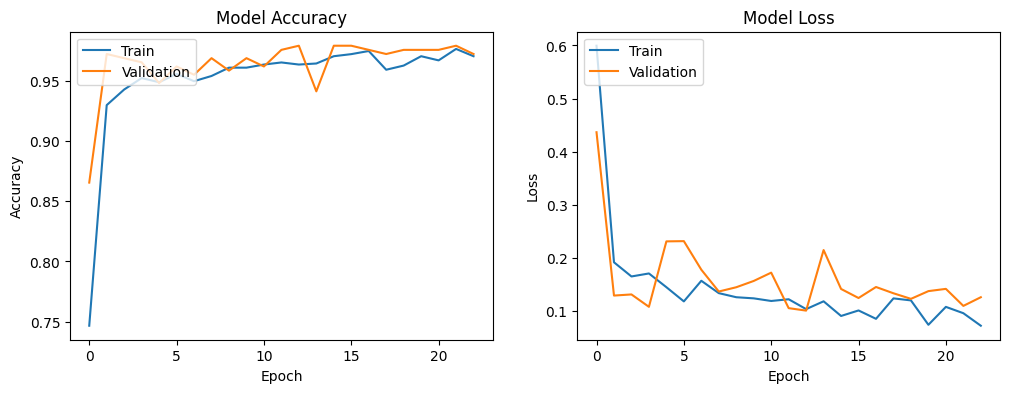

{'accuracy': 0.982758641242981, 'loss': 0.1075378879904747}

		Model saved




		Confusion matrix



10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 585ms/step


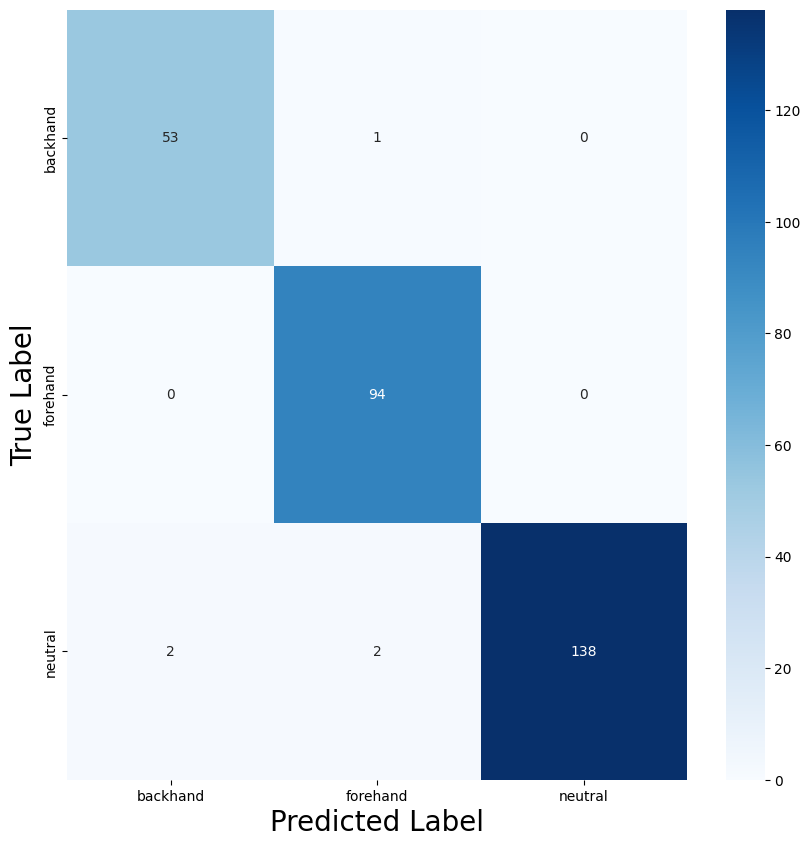

In [35]:
model_training("simpleRNN")

## GRU RNN Model




		Model created





Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_arm            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk (InputLayer)  │ (None, 30, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_arm           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_leg            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_leg           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_left_arm        │ (None, 30, 128)   │     27,648 │ left_arm[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_trunk           │ (None, 30, 128)   │     28,416 │ trunk[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_right_arm       │ (None, 30, 128)   │     27,648 │ right_arm[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_left_leg        │ (None, 30, 128)   │     27,648 │ left_leg[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl1_right_leg       │ (None, 30, 128)   │     27,648 │ right_leg[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_leftArm_trunk   │ (None, 30, 256)   │          0 │ bl1_left_arm[0][… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_rightArm_trunk  │ (None, 30, 256)   │          0 │ bl1_right_arm[0]… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_lafetLeg_trunk  │ (None, 30, 256)   │          0 │ bl1_left_leg[0][… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fl1_rightLeg_trunk  │ (None, 30, 256)   │          0 │ bl1_right_leg[0]… │
│ (Concatenate)       │                   │            │ bl1_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_leftArm_trunk   │ (None, 30, 192)   │    203,904 │ fl1_leftArm_trun… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_rightArm_trunk  │ (None, 30, 192)   │    203,904 │ fl1_rightArm_tru… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bl2_leftLeg_trunk   │ (None, 30, 192)   │    203,904 │ fl1_lafetLeg_tru… │
│ (Bidirectional)     │                   │            │                 

 Total params: 3,451,139 (13.17 MB)

 Trainable params: 3,451,139 (13.17 MB)

 Non-trainable params: 0 (0.00 B)


		Checkpointer defined


		Early stopper defined




		Starting fitting process



Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6359 - loss: 0.7818
Epoch 1: val_loss improved from inf to 0.15055, saving model to weights_GRU.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 27s 158ms/step - accuracy: 0.6401 - loss: 0.7744 - val_accuracy: 0.9517 - val_loss: 0.1505
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9172 - loss: 0.2680
Epoch 2: val_loss did not improve from 0.15055
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9174 - loss: 0.2674 - val_accuracy: 0.9414 - val_loss: 0.1882
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9566 - loss: 0.1368
Epoch 3: val_loss improved from 0.15055 to 0.12131, saving model to weights_GRU.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.9565 - loss: 0.1375 - val_accuracy: 0.9759 - val_loss: 0.1213
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9630 - loss: 0.1011
Epoch 

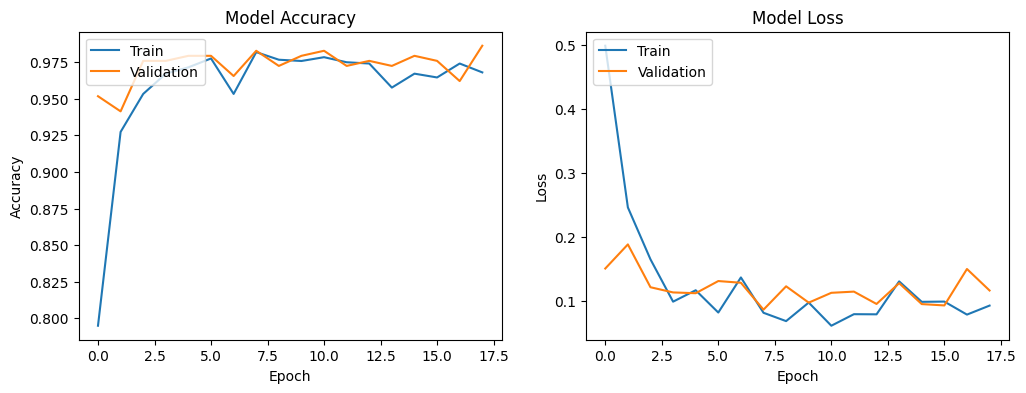

{'accuracy': 0.982758641242981, 'loss': 0.08687353134155273}

		Model saved




		Confusion matrix



10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step


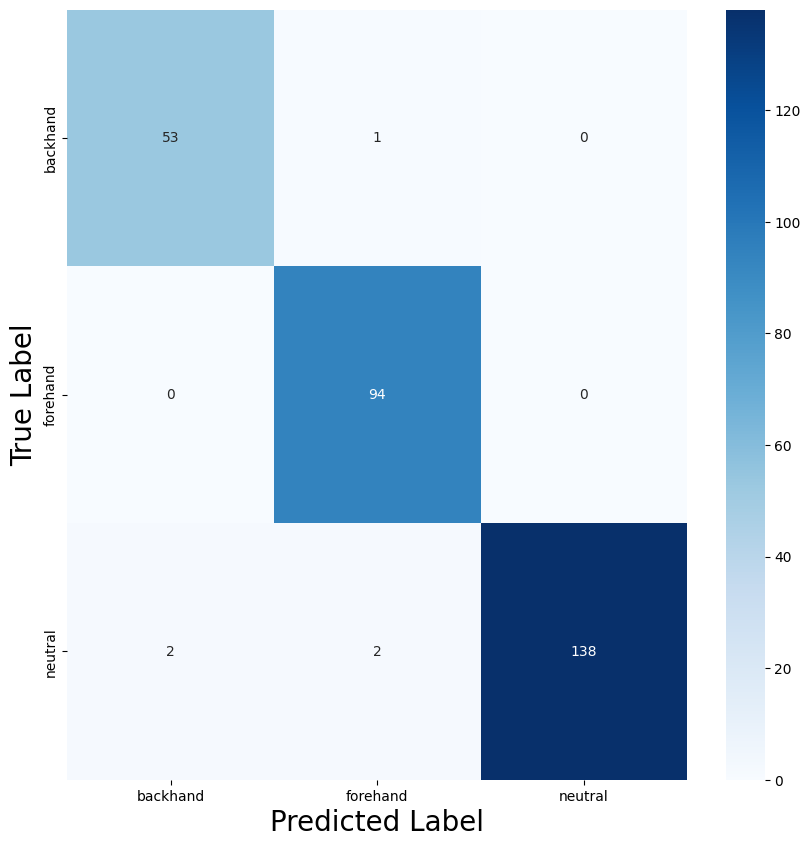

In [36]:
model_training("gru")

# TCN

In [27]:
def create_tcn_network(
    shape_left_arm = 6,
    shape_right_arm = 6,
    shape_left_leg = 6,
    shape_right_leg = 6,
    shape_trunk = 8,
    n_classes = 3,
    T = 30,
):


  # ==== Inputs ====

  in_left_arm  = Input(shape=(T, shape_left_arm),  name = "left_arm")
  in_right_arm = Input(shape=(T, shape_right_arm), name = "right_arm")
  in_left_leg  = Input(shape=(T, shape_left_leg),  name = "left_leg")
  in_right_leg = Input(shape=(T, shape_right_leg), name = "right_leg")
  in_trunk     = Input(shape=(T, shape_trunk),     name = "trunk")

  # ==== First TCN Layer ====

  tcn_left_arm  = TCN(nb_filters=32, kernel_size=5, dilations=[1, 2, 4], return_sequences=True, name="tcn_left_arm") (in_left_arm)
  tcn_right_arm = TCN(nb_filters=32, kernel_size=5, dilations=[1, 2, 4], return_sequences=True, name="tcn_right_arm")(in_right_arm)
  tcn_left_leg  = TCN(nb_filters=32, kernel_size=5, dilations=[1, 2, 4], return_sequences=True, name="tcn_left_leg") (in_left_leg)
  tcn_right_leg = TCN(nb_filters=32, kernel_size=5, dilations=[1, 2, 4], return_sequences=True, name="tcn_right_leg")(in_right_leg)
  tcn_trunk     = TCN(nb_filters=48, kernel_size=5, dilations=[1, 2, 4], return_sequences=True, name="tcn_trunk")    (in_trunk)

  # ==== Concatenation ====

  tcn_results_concatenation = layers.Concatenate(name="tcn_results_concatenation")  ([tcn_left_arm, tcn_right_arm, tcn_left_leg, tcn_right_leg, tcn_trunk])

  # ==== Last TCN Layer ====

  tcn_results = TCN(nb_filters=128, kernel_size=5, dilations=[1, 2, 4], return_sequences=False, name="tcn_results") (tcn_results_concatenation)

  # ==== Fully Connected Layers

  fc = layers.Dense(256, activation='relu', name="fc")(tcn_results)
  fc = layers.Dropout(0.3)(fc)

  # ==== Softmax Layer ====

  out = layers.Dense(n_classes, activation="softmax", name="out")(fc)

  model = models.Model(
      inputs=[in_left_arm, in_right_arm, in_trunk, in_left_leg, in_right_leg],
      outputs=out,
      )

  return model




		Model created





Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ left_arm            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_arm           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_leg            │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_leg           │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ trunk (InputLayer)  │ (None, 30, 8)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_left_arm (TCN)  │ (None, 30, 32)    │     26,976 │ left_arm[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_right_arm (TCN) │ (None, 30, 32)    │     26,976 │ right_arm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_left_leg (TCN)  │ (None, 30, 32)    │     26,976 │ left_leg[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_right_leg (TCN) │ (None, 30, 32)    │     26,976 │ right_leg[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_trunk (TCN)     │ (None, 30, 48)    │     60,240 │ trunk[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_results_concat… │ (None, 30, 176)   │          0 │ tcn_left_arm[0][… │
│ (Concatenate)       │                   │            │ tcn_right_arm[0]… │
│                     │                   │            │ tcn_left_leg[0][… │
│                     │                   │            │ tcn_right_leg[0]… │
│                     │                   │            │ tcn_trunk[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcn_results (TCN)   │ (None, 128)       │    545,664 │ tcn_results_conc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc (Dense)          │ (None, 256)       │     33,024 │ tcn_results[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ fc[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 3)         │        771 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 747,603 (2.85 MB)

 Trainable params: 747,603 (2.85 MB)

 Non-trainable params: 0 (0.00 B)


		Checkpointer defined


		Early stopper defined




		Starting fitting process



Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.4500 - loss: 2.6936
Epoch 1: val_loss improved from inf to 0.35359, saving model to weights_TCN.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 57s 647ms/step - accuracy: 0.4536 - loss: 2.6623 - val_accuracy: 0.8862 - val_loss: 0.3536
Epoch 2/100
33/37 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9191 - loss: 0.2764
Epoch 2: val_loss did not improve from 0.35359
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9199 - loss: 0.2730 - val_accuracy: 0.9103 - val_loss: 0.3637
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9325 - loss: 0.2064
Epoch 3: val_loss improved from 0.35359 to 0.07740, saving model to weights_TCN.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9330 - loss: 0.2053 - val_accuracy: 0.9793 - val_loss: 0.0774
Epoch 4/100
34/37 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9757 - loss: 0.0926
Epoch 

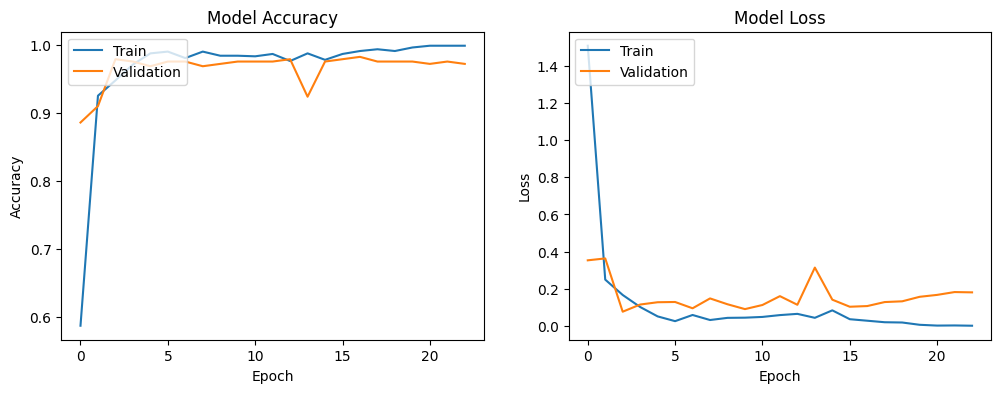

{'accuracy': 0.9448275566101074, 'loss': 0.16852307319641113}

		Model saved




		Confusion matrix



10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 379ms/step


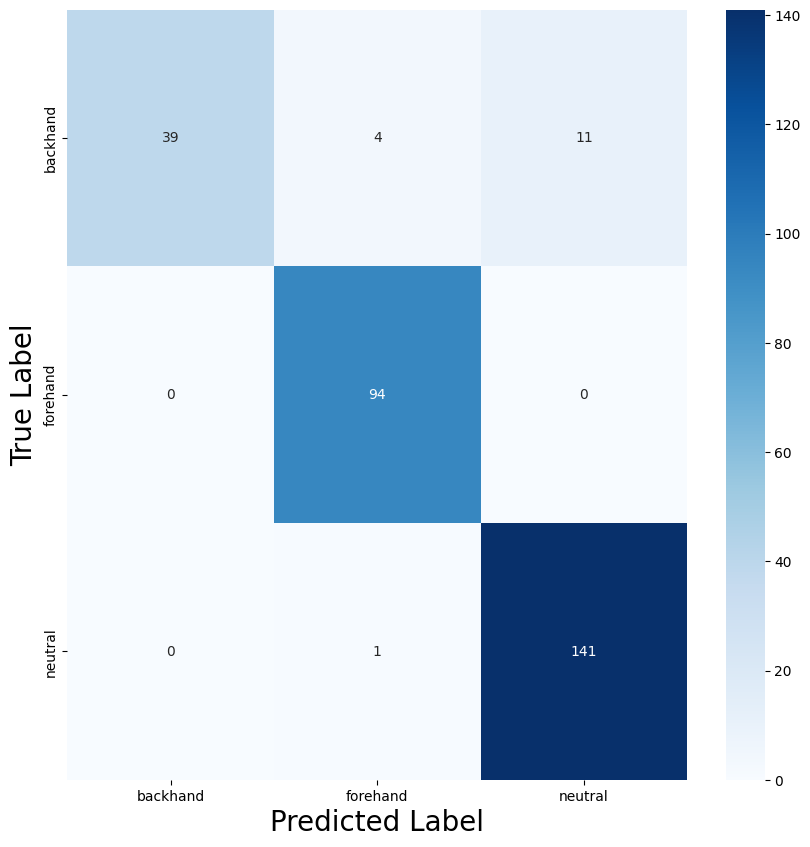

In [30]:
model = create_tcn_network()

print("\n=================================================\n")
print("\n\t\tModel created\n")
print("\n=================================================\n")

model.summary()

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

checkpointer = ModelCheckpoint(
  filepath="weights_TCN.keras",
  verbose=1,
  save_best_only=True,
  monitor='val_loss'
  )

print("\n\t\tCheckpointer defined\n")

early_stopper = EarlyStopping(
  monitor = 'val_loss',
  patience = 20,
  verbose = False,
  restore_best_weights = True
  )

print("\n\t\tEarly stopper defined\n")

print("\n=================================================\n")
print("\n\t\tStarting fitting process\n")
print("\n=================================================\n")

history = model.fit(
  [Xla_tr, Xra_tr, Xt_tr, Xll_tr, Xrl_tr], y_tr,
  validation_data = ([Xla_te, Xra_te, Xt_te, Xll_te, Xrl_te], y_te),
  epochs = 100,
  batch_size = 32,
  verbose=1,
  callbacks=[checkpointer, early_stopper],
  class_weight=class_weights_dict
  )


results = model.evaluate(
  [Xla_te, Xra_te, Xt_te, Xrl_te, Xll_te],
  y_te,
  return_dict=True
  )

print("\n\t\tEvaluation done\n")

print("\n=================================================\n")
print("\n\t\tResults\n")
print("\n=================================================\n")

plot_history(history)

print(results)

model_file_path = "/content/drive/MyDrive/University/Deep/Tennis-Shot-Recognition/"

model.save(model_file_path + "Shot_Classification_TCN.keras")

print("\n\t\tModel saved\n")

print("\n=================================================\n")
print("\n\t\tConfusion matrix\n")
print("\n=================================================\n")

%matplotlib inline

cm = confusion_matrix(y_true=np.argmax(y_te, axis=1), y_pred=np.argmax(model.predict([Xla_te, Xra_te, Xt_te, Xrl_te, Xll_te]), axis=1))
df_cm = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
plt.figure(figsize=(10,10))
sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='.4g')
plt.xlabel('Predicted Label', fontsize=20)
plt.ylabel('True Label', fontsize=20)
plt.show()